In [ ]:
!pip install pcapy
import pcapy
from scapy.all import *
import matplotlib.pyplot as plt
from scapy.layers.l2 import Ether


# Network interface to capture packets from
interface = "en0"

# Capture duration in seconds
capture_duration = 2

# Function to process captured packets
def process_packet(header, data):
    try:
        packet_scapy = Ether(data)
        protocol = packet_scapy.getlayer(2).name
        protocol_counts[protocol] += 1
        total_bytes[protocol] += len(data)
    except Exception as e:
        print(f"Error processing packet: {e}")  # Print any errors encountered

# Initialize dictionaries to store protocol counts and total bytes
protocol_counts = defaultdict(int)
total_bytes = defaultdict(int)

# Capture packets
print(f"Capturing packets on interface {interface} for {capture_duration} seconds...")
cap = pcapy.open_live(interface, 65536, 1, 0)
cap.loop(capture_duration, process_packet)

# Visualize results
protocols = list(protocol_counts.keys())
counts = list(protocol_counts.values())
bytes_transferred = list(total_bytes.values())

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.bar(protocols, counts)
plt.title("Packets per Protocol")
plt.xlabel("Protocol")
plt.ylabel("Number of Packets")

plt.subplot(1, 2, 2)
plt.bar(protocols, bytes_transferred)
plt.title("Total Bytes Transferred per Protocol")
plt.xlabel("Protocol")
plt.ylabel("Total Bytes")

plt.tight_layout()
plt.show()


  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


ModuleNotFoundError: No module named 'pcapy'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 22.3 MB/s eta 0:00:00
Capturing packets on interface eth0 for 2 seconds...


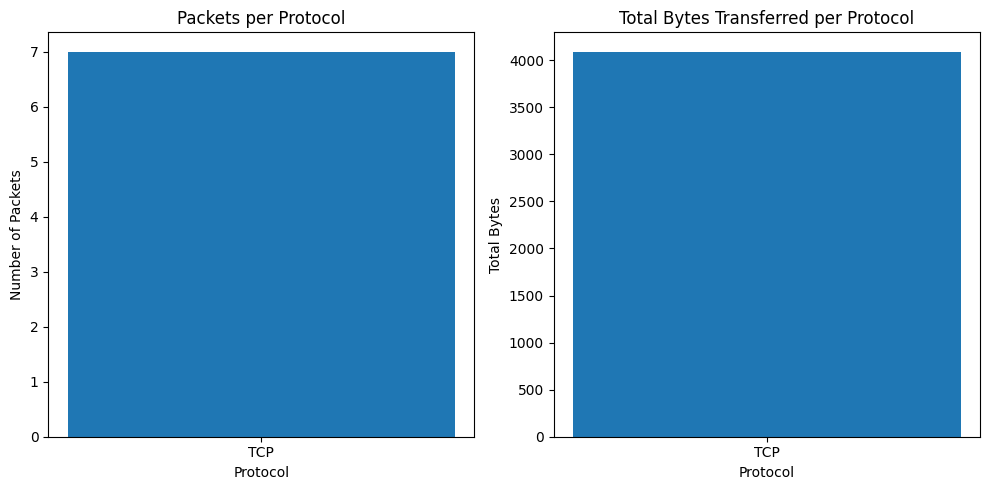

In [ ]:
!pip install scapy
from scapy.all import *
import matplotlib.pyplot as plt
from scapy.layers.l2 import Ether
from collections import defaultdict


# Network interface to capture packets from
interface = "eth0" # Change en0 to eth0 or your interface

# Capture duration in seconds
capture_duration = 2

# Function to process captured packets
def process_packet(packet):
    try:
        # Get protocol from layer 2
        protocol = packet.getlayer(2).name
        protocol_counts[protocol] += 1
        total_bytes[protocol] += len(packet)  # Get total bytes
    except Exception as e:
        print(f"Error processing packet: {e}")  # Print any errors encountered

# Initialize dictionaries to store protocol counts and total bytes
protocol_counts = defaultdict(int)
total_bytes = defaultdict(int)

# Capture packets
print(f"Capturing packets on interface {interface} for {capture_duration} seconds...")
packets = sniff(iface=interface, timeout=capture_duration, prn=process_packet)

# Visualize results
protocols = list(protocol_counts.keys())
counts = list(protocol_counts.values())
bytes_transferred = list(total_bytes.values())

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.bar(protocols, counts)
plt.title("Packets per Protocol")
plt.xlabel("Protocol")
plt.ylabel("Number of Packets")

plt.subplot(1, 2, 2)
plt.bar(protocols, bytes_transferred)
plt.title("Total Bytes Transferred per Protocol")
plt.xlabel("Protocol")
plt.ylabel("Total Bytes")

plt.tight_layout()
plt.show()

In [ ]:
!pip install scapy
!apt-get update
!apt-get install libpcap-dev -y
from scapy.all import *

def packet_callback(packet):

    print(f"Source: {packet[IP].src}, Destination: {packet[IP].dst}, Protocol: {packet[IP].proto}")

# Start sniffing packets on a specific interface (e.g., 'eth0')
sniff(iface="eth0", prn=packet_callback, filter="ip", store=0)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 46.1 MB/s eta 0:00:00
Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,626 B]
Hit:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,517 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [2,859 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [3,663 kB]
Get:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/

<Sniffed: TCP:0 UDP:0 ICMP:0 Other:0>